<a href="https://colab.research.google.com/github/tlmakinen/degeneracy_distillery/blob/main/tutorial_notebooks/sir_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIR — Finding R₀ = β/γ

An end-to-end run of the **Degeneracy Distillery** on the SIR
epidemiological model.


* **Parameters**: θ = (β, γ, I₀/10).
* **Data**: noisy I(t)/N at 30 time points.
* **Ground truth**: only R₀ = β/γ is identifiable from incidence
  alone; β and γ are individually degenerate.


**NOTE:** results will vary slightly based on allocated device and runtime type.

In [1]:
# Colab setup (skip if running locally with the package installed).
!git clone https://github.com/tlmakinen/degeneracy_distillery.git
%cd /content/degeneracy_distillery
!pip install -q -e .
%cd /content/
!git clone https://github.com/DeaglanBartlett/ESR.git
%cd /content/ESR
!pip install -q -e .


Cloning into 'degeneracy_distillery'...
remote: Enumerating objects: 936, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 936 (delta 88), reused 86 (delta 33), pack-reused 784 (from 1)
Receiving objects: 100% (936/936), 39.51 MiB | 18.71 MiB/s, done.
Resolving deltas: 100% (619/619), done.
/content/degeneracy_distillery
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.6/365.6 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 18.1 MB/s eta 0:00:

**Restart the runtime** before continuing on Colab.

In [ ]:
import os
os.kill(os.getpid(), 9)  # uncomment in Colab to restart


In [1]:
import esr.generation.generator  # ESR sanity check
import numpy as np
import jax, jax.numpy as jnp, jax.random as jr
import matplotlib.pyplot as plt
import sympy
from scipy.integrate import odeint
from tqdm import tqdm
import flax.linen as nn

from degeneracy_distillery.training_loop_fishnets import train_fishnets
from degeneracy_distillery.training_loop_flatten import fit_flattening
from degeneracy_distillery.align_coords import load_and_process_data_v2
from degeneracy_distillery.preprocessing_utils import weighted_std
from degeneracy_distillery.sr_utils import (
    fit_and_analyze_sr, analyze_equations, sr_structure_predicate,
    check_symbolic_invertibility,
    fit_theta_scaler, expressions_to_physical,
)
from degeneracy_distillery.postprocess_new import (
    analyze_atom_sharing, regroup_like_terms,
)
from degeneracy_distillery.postprocessing_utils import (
    print_discovered_expressions, get_y_sr,
    flatten_with_numerical_jacobian, check_flattening,
)

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'figure.figsize': (8, 5), 'figure.dpi': 130,
    'savefig.dpi': 200, 'savefig.bbox': 'tight',
})


## 1. Simulator and data generation

In [2]:
key = jr.PRNGKey(42)
np.random.seed(42)

N_pop, I0_mean = 1000, 8
n_timepoints, t_max = 30, 50.0
t_obs = np.linspace(0, t_max, n_timepoints)
noise_std = 0.05

BETA_MIN, BETA_MAX = 0.1, 1.0
GAMMA_MIN, GAMMA_MAX = 0.05, 0.5
nsims = 500
delta = 0.15  # supercriticality cut: keep beta/gamma >= 1 + delta


def sir_odes(y, _t, beta, gamma, N):
    S, I, R = y
    return [-beta * S * I / N, beta * S * I / N - gamma * I, gamma * I]


def simulate_sir(beta, gamma, noise_key):
    I0 = np.random.poisson(I0_mean)
    S0 = N_pop - I0
    sol = odeint(sir_odes, [S0, I0, 0.0], t_obs, args=(beta, gamma, N_pop))
    I_t = sol[:, 1] / N_pop
    I_t = I_t + np.array(jr.normal(noise_key, shape=I_t.shape)) * noise_std
    return I_t.astype(np.float32), I0 / 10.0


def generate(rng_key, n, label):
    key1, key2 = jr.split(rng_key)
    pool = max(4 * n, 4 * nsims)
    beta_pool = np.random.uniform(BETA_MIN, BETA_MAX, pool)
    gamma_pool = np.random.uniform(GAMMA_MIN, GAMMA_MAX, pool)
    keep = (beta_pool / gamma_pool) >= (1.0 + delta)
    beta_pool = beta_pool[keep][:n]
    gamma_pool = gamma_pool[keep][:n]
    keys = jr.split(key2, n)
    data, I0s = [], []
    for i in tqdm(range(n), desc=label):
        d, i0 = simulate_sir(beta_pool[i], gamma_pool[i], keys[i])
        data.append(d); I0s.append(i0)
    theta = np.stack([beta_pool, gamma_pool, np.array(I0s)], axis=1).astype(np.float32)
    return theta, np.array(data, dtype=np.float32)


key, sub = jr.split(key)
theta_train, data_train = generate(sub, nsims, "train")
key, sub = jr.split(key)
theta_test,  data_test  = generate(sub, nsims, "test")
print("theta_train", theta_train.shape, "data_train", data_train.shape)


test: 100%|██████████| 500/500 [00:01<00:00, 338.19it/s]

theta_train (500, 3) data_train (500, 30)


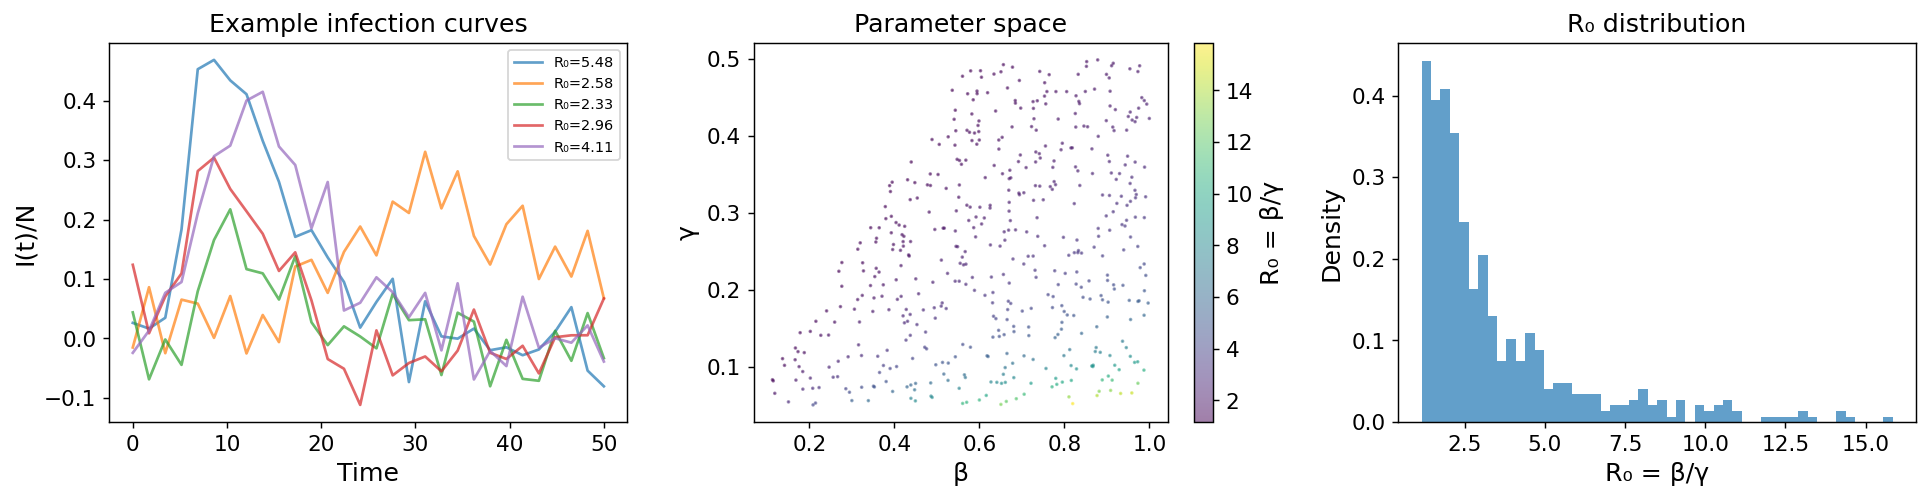

In [3]:
# Plot example SIR curves for different R_0 values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Example curves
for idx in np.random.choice(nsims, 5, replace=False):
    R0_val = theta_train[idx, 0] / theta_train[idx, 1]
    axes[0].plot(t_obs, data_train[idx], alpha=0.7, label=f'R₀={R0_val:.2f}')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('I(t)/N')
axes[0].set_title('Example infection curves')
axes[0].legend(fontsize=8)

# Parameter space colored by R_0
R0_vals = np.array(theta_train[:, 0] / theta_train[:, 1])
sc = axes[1].scatter(theta_train[:, 0], theta_train[:, 1], c=R0_vals,
                     s=1, alpha=0.5, cmap='viridis')
plt.colorbar(sc, ax=axes[1], label='R₀ = β/γ')
axes[1].set_xlabel('β')
axes[1].set_ylabel('γ')
axes[1].set_title('Parameter space')

# R_0 distribution
axes[2].hist(R0_vals, bins=50, density=True, alpha=0.7)
axes[2].set_xlabel('R₀ = β/γ')
axes[2].set_ylabel('Density')
axes[2].set_title('R₀ distribution')

plt.tight_layout()
plt.savefig('sir_data_overview.pdf')
plt.show()

## 2. Pre-fishnet rescaling

`fit_theta_scaler` is the single source of truth for the scaling map; we keep
it around and reuse it for the SR sample pool and for the final
physical-θ substitution.

In [4]:
scaler = fit_theta_scaler(theta_train, feature_range=(1.0, 2.0))
theta_train_s = scaler.transform(theta_train).astype(np.float32)
theta_test_s  = scaler.transform(theta_test).astype(np.float32)
print("data_min:", scaler.data_min_)
print("data_max:", scaler.data_max_)
print("scaled range:", theta_train_s.min(0), theta_train_s.max(0))


data_min: [0.1130902  0.05006061 0.1       ]
data_max: [0.9997459  0.49901938 1.5       ]
scaled range: [1. 1. 1.] [2. 2. 2.]


## 3. Fisher-network ensemble

We feed the network only `(β_s, γ_s)`; `I0/10` is a per-realization
nuisance, so it is excluded from the Fishnet target.

In [5]:
embedding_net = nn.Sequential([
    nn.Dense(64), nn.gelu,
    nn.Dense(32), nn.gelu,
])

_ = train_fishnets(
    theta_train_s[:, :2], data_train,
    theta_test_s[:, :2],  data_test,
    num_models=10,
    train_epochs=5000, patience=30,
    n_layers=[2, 5], hids_min=50, hids_max=300,
    embedding_net=embedding_net,
    lr=5e-5, train_batch_size=50,
    outdir="fishnets-sir",
)


saving to fishnets-sir
data_test shape: (500, 30)
theta_test shape: (500, 2)
Chosen hidden size for model 1 : 89 | layers: 5
Chosen hidden size for model 2 : 120 | layers: 2
Chosen hidden size for model 3 : 276 | layers: 5
Chosen hidden size for model 4 : 139 | layers: 5
Chosen hidden size for model 5 : 225 | layers: 2
Chosen hidden size for model 6 : 263 | layers: 5
Chosen hidden size for model 7 : 164 | layers: 4
Chosen hidden size for model 8 : 95 | layers: 4
Chosen hidden size for model 9 : 119 | layers: 5
Chosen hidden size for model 10 : 191 | layers: 2
STARTING TRAINING LOOP

Training model 1 of 10


Epoch 1931 loss: -5.79027 ; val_loss: -4.82709:  39%|███▊      | 1931/5000 [00:49<01:18, 39.23it/s]



Early stopping triggered at epoch 1931

Training model 2 of 10


Epoch 1384 loss: -5.44078 ; val_loss: -4.62077:  28%|██▊       | 1384/5000 [00:28<01:15, 47.97it/s]



Early stopping triggered at epoch 1384

Training model 3 of 10


...


Early stopping triggered at epoch 1574

Training model 9 of 10


Epoch 1302 loss: -5.70136 ; val_loss: -4.56778:  26%|██▌       | 1302/5000 [00:35<01:39, 37.09it/s]



Early stopping triggered at epoch 1302

Training model 10 of 10


Epoch 1346 loss: -5.61678 ; val_loss: -4.53473:  27%|██▋       | 1346/5000 [00:29<01:19, 46.21it/s]



Early stopping triggered at epoch 1346
Ensemble weights: [134.51668  102.091576 119.18642   69.35999  107.74703  118.28738
 123.92681  114.34729  112.0315    99.76149 ]
Training completed. Outputs saved to: fishnets-sir/fishnets_outputs.npz
Note: Load with io_utils.load_fishnets_results(file) for alias support


## 4. Flattening Network


In [6]:
fish = np.load("fishnets-sir/fishnets_outputs.npz")
thetas = jnp.array(fish["theta"])
ensemble_weights = fish["ensemble_weights"]
F_network_ensemble = jnp.array(fish["Fs"])

w, ensemble_ws, output_dict, flatten_model = fit_flattening(
    F_network_ensemble=F_network_ensemble,
    θs=thetas,
    ensemble_weights=ensemble_weights,
    flattener_activation="softplus",
    loss_type="log_frob",
    forward_backward_mlp=True,
    forward_backward_invertibility_weight=1.0,
    n_layers=8,
    offset=0.0, beta_det=0.1, noise=1e-2,
    batch_size=50,
    finetune_epochs=200, epochs_phase1=1000, epochs_phase2=500,
    lr_phase1=2e-6, lr_schedule_initial=7e-5, lr_decay=0.3,
    l1_alpha=0.0, do_plot=False,
    Fisher_to_flatten="average",
    output_prefix="sir_flatten",
    return_model=True,
)


AVERAGING FISHERS (weighted ensemble)
COMPUTING ROBUST NORM FACTOR (method: median_max_eig)
norm_factor = 865.215
COMPUTING WHITENING TRANSFORM
Global mean Fisher shape: (2, 2)
Global mean Fisher:
[[ 0.5879836  -0.41556874]
 [-0.41556874  2.0763428 ]]
Mean Fisher eigenvalues: [0.4798131 2.1845133]
W_inv transformation:  [[ 0.74251765 -0.19144504]
 [-0.191445    1.4281777 ]]
Whitened Fisher global mean (should be ~I):
[[1.0000001e+00 5.9604645e-08]
 [5.9604645e-08 9.9999982e-01]]
W_inv condition number: 2.13
Flattener activation: softplus
Loss type: log_frob
Min-max input scaling: True
Min-max post-scale offset: 0.0
USING WHITENED forward–backward MLP (forward WhitenedMLP + ReversePathMLP)
TRAINING FLATTENER NET


epoch 999 loss: 0.6927, det F(η): 1.4529, val det F(η): 1.5607: 100%|██████████| 1000/1000 [01:09<00:00, 14.32it/s]


FINE-TUNING FLATTENER NET


epoch 499 loss: 0.6649, det F(η): 1.4934, val det F(η): 1.4218: 100%|██████████| 500/500 [00:35<00:00, 14.05it/s]


FINE-TUNING EACH ENSEMBLE MEMBER
fine-tuning for ensemble member 0


...

fine-tuning for ensemble member 8


epoch 199 loss: 0.6789, det F(η): 1.4996, val det F(η): 1.4367: 100%|██████████| 200/200 [00:21<00:00,  9.26it/s]


fine-tuning for ensemble member 9


epoch 199 loss: 0.6967, det F(η): 1.1129, val det F(η): 1.2496: 100%|██████████| 200/200 [00:23<00:00,  8.41it/s]


applying model to ensemble member 0
applying model to ensemble member 1
applying model to ensemble member 2
applying model to ensemble member 3
applying model to ensemble member 4
applying model to ensemble member 5
applying model to ensemble member 6
applying model to ensemble member 7
applying model to ensemble member 8
applying model to ensemble member 9
ROTATING ENSEMBLE COORDINATES
Note: Load with io_utils.load_flattening_results(file) for alias support
EXPERIMENT COMPLETED & RESULTS SAVED TO: sir_flatten.npz
Saved flattener module + weights to: sir_flatten_flatten_model.pkl


## 5. SR-only sample pool

Cheap pool of θ samples (no simulator, just θ) we feed through the
trained flattener for the SR step.  We pass them through the *same* scaler
that the fishnets saw.

In [7]:
rng_sr = np.random.default_rng(456)
n_sr = 10_000

beta_sr  = rng_sr.uniform(BETA_MIN, BETA_MAX, n_sr)
gamma_sr = rng_sr.uniform(GAMMA_MIN, GAMMA_MAX, n_sr)
I0_sr    = rng_sr.poisson(I0_mean, n_sr) / 10.0
theta_sr_phys = np.stack([beta_sr, gamma_sr, I0_sr], axis=1).astype(np.float32)

# supercriticality cut, mirroring the training set
keep = (beta_sr / gamma_sr) >= (1.0 + delta)
theta_sr_phys = theta_sr_phys[keep]

# scale and select the (beta_s, gamma_s) channels the fishnet was trained on
X_sr = scaler.transform(theta_sr_phys)[:, :2].astype(np.float32)

ys_sr = jnp.array([
    jax.vmap(lambda x: flatten_model.apply(w_i, x))(X_sr)
    for w_i in ensemble_ws
])
print("X_sr", X_sr.shape, "ys_sr", ys_sr.shape)


X_sr (7602, 2) ys_sr (10, 7602, 2)


## 6. Coordinate alignment

`align_coords.load_and_process_data_v2` runs Procrustes+sign canonicalization
on the ensemble Jacobians and returns the aligned `(X, y, dy_sr, Fs)` we feed
to symbolic regression.

In [8]:
data = load_and_process_data_v2(
    datapath="./",
    filename="sir_flatten.npz",
    num_samps=4000, seed=44,
    process_ensemble=True, n_d=1.0,
    align_mode="procrustes",
    separate_nonlinearity=False,
    canonicalize="sign_only",
    use_prior_normalization=True,
    restore_reference_mean=False,
    Fisher_to_flatten="average",
    verbose=False,
)

X = data["X"]
m  = X[:, 0] > 0.0   # standard mask for the small SIR run
X, y, y_std, dy_sr, Fs = X[m], data["y"][m], data["y_std"][m], data["dy_sr"][m], data["Fs"][m]
ys = np.array([yy[m] for yy in data["ys"]])
n_params = X.shape[1]

# floor y so y >= 1 (PyOperon-friendly)
ymin_ = y.min(0) - 1.0
y -= ymin_
ys -= ymin_

# rotate the SR pool into the same aligned frame
ys_sr_rot = np.array([
    np.einsum("ij,bj->bi", data["rotmats"][i], ys_sr[i] - ys_sr[i].mean(0))
    for i in range(len(ys_sr))
])
y_std_sr = weighted_std(ys_sr_rot, data["ensemble_weights"])
y_sr = np.average(ys_sr_rot, 0, data["ensemble_weights"])
ys_sr_rot -= y_sr.min(0); y_sr -= y_sr.min(0)
y_sr += 1; ys_sr_rot += 1
print("aligned X", X.shape, "y", y.shape)


aligned X (500, 2) y (500, 2)


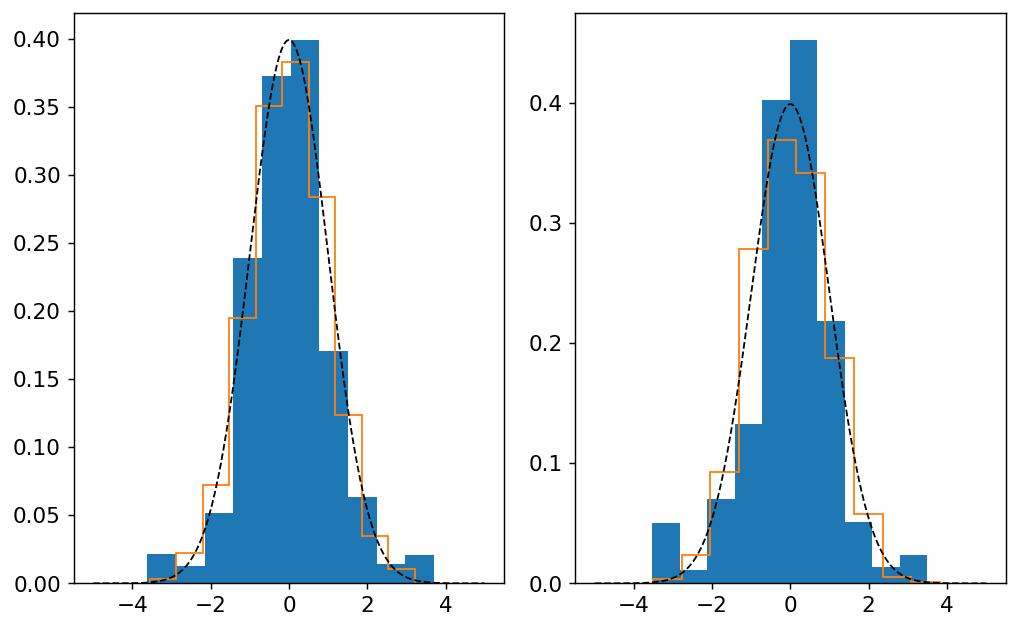

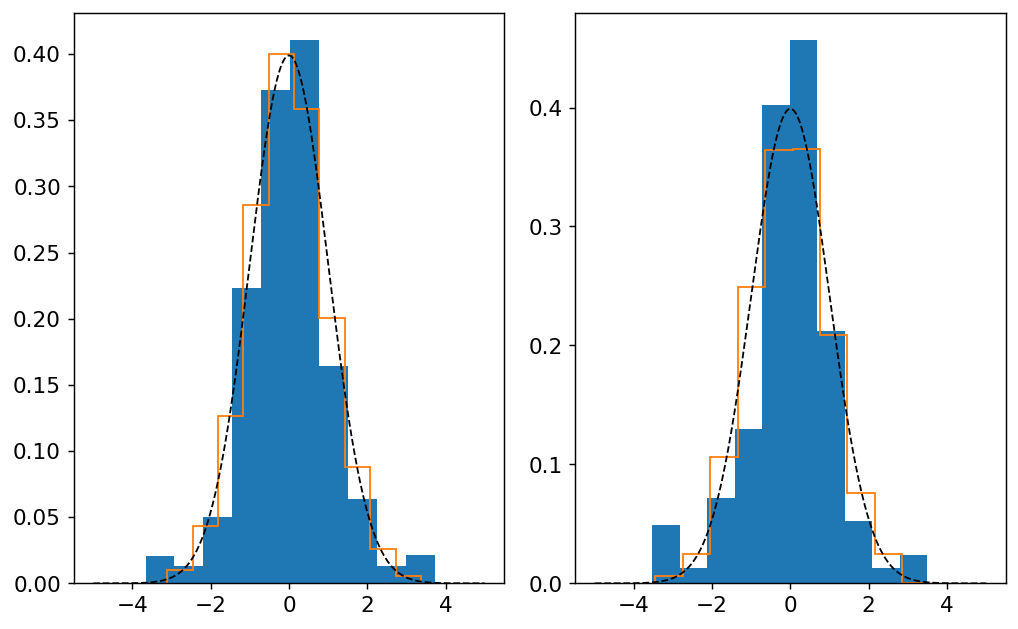

In [9]:
# check coordinate sampling distribution

fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys[:, :, ...] - y) / y_std)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()


fig,axs = plt.subplots(1,n_params)
axs = axs.flatten()

bins = [-5, 5]

for i,ax in enumerate(axs):
    ax.hist(((ys_sr_rot - y_sr) / y_std_sr)[:, :, i].flatten(), density=True)
    ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)
    ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")

    # ax.set_xlim(-10, 10)
plt.tight_layout()
plt.show()

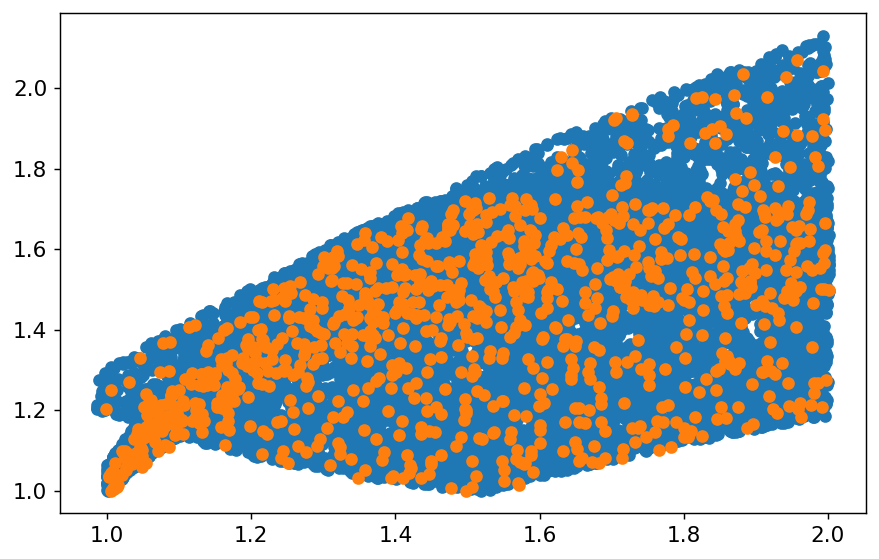

In [10]:
plt.scatter(X_sr, y_sr)
plt.scatter(X, y)

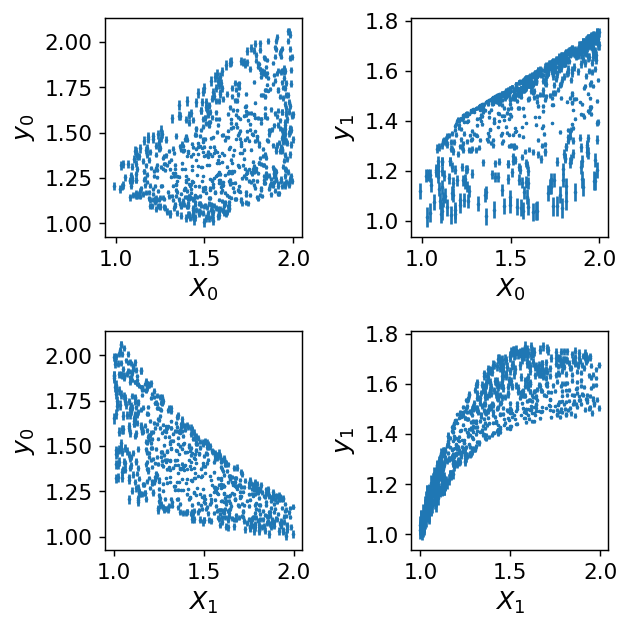

In [11]:
# create scatterplot to see how y responds to X

fig, axs = plt.subplots(n_params, n_params, figsize=(5,5))

skip=10

for i in range(X_sr.shape[-1]):
    for j in range(y_sr.shape[-1]):

        # row, column
        axs[i,j].errorbar(X_sr[::skip,i], y_sr[::skip, j], yerr=y_std_sr[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i))
        axs[i,j].set_ylabel(r"$y_%d$"%(j))

plt.tight_layout()
plt.show()

## 7. Symbolic regression

In [42]:
SR_OFFSET = 0.0   # what we add to X before feeding PyOperon

from degeneracy_distillery.sr_utils import fit_symbolic_regression

fit_symbolic_regression(
    X_sr, y_sr, y_std_sr,
    parent_dir='./sr_results_sir/',
    random_state=32134,
    time_limit=60*1,
    max_length=25,
    max_depth=10,
    allowed_symbols='add,mul,div,pow,constant,variable',
    )


Fitting component 1 of 2 (index 0)
X train shape: (7602, 2), y train shape: (7602,)
Fitting...
Done!
Best model: ((-1.60) + (2.15 * ((0.30 * X2) ^ ((-0.24) * X1))))
Stats: {'model_length': 7, 'model_complexity': 11, 'generations': 13, 'evaluation_count': 0, 'residual_evaluations': 101781, 'jacobian_evaluations': 62766, 'random_state': 32134}
Outputting 12 individuals on Pareto front
Outputting 2000 individuals in population

Fitting component 2 of 2 (index 1)
X train shape: (7602, 2), y train shape: (7602,)
Fitting...
Done!
Best model: (0.02 + (0.99 * (((102.55 * X2) + (-102.08)) ^ (0.07 * X1))))
Stats: {'model_length': 9, 'model_complexity': 13, 'generations': 11, 'evaluation_count': 0, 'residual_evaluations': 89349, 'jacobian_evaluations': 54398, 'random_state': 32134}
Outputting 9 individuals on Pareto front
Outputting 2000 individuals in population


In [43]:
mdl_coords, frob_coords, analysis = analyze_equations(
    X + SR_OFFSET, y, y_std, dy_sr, Fs,
    parent_dir="sr_results_sir/",
    n_params=n_params,
    equation_set="pareto",
    max_complexity_thresh=20,
    length_penalty=2.0,
    equation_predicate=sr_structure_predicate(
        n_params=n_params,
        forbid_self_transcendental=True,
        check_nested_exp=False,
    ),
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in mdl_coords])



Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
8 equations below complexity threshold 20
2 / 8 equations pass equation_predicate (skipped 6)

Best MDL equation (complexity=9):
  (0.231838 + (1.532784 * (((-0.188487) + ((-0.852931) * X1)) / ((-1.465492) * X2))))
  LaTeX: $b_{0} + \frac{b_{1} \left(X_{1} b_{3} + b_{2}\right)}{X_{2} b_{4}}$

Best Frob loss equation (complexity=9):
  (0.231838 + (1.532784 * (((-0.188487) + ((-0.852931) * X1)) / ((-1.465492) * X2))))
  LaTeX: $b_{0} + \frac{b_{1} \left(X_{1} b_{3} + b_{2}\right)}{X_{2} b_{4}}$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
7 equations below complexity threshold 20
1 / 7 equations pass equation_predicate (skipped 6)

Best MDL equation (complexity=5):
  (0.707166 + (0.524658 * (0.998278 * X2)))
  LaTeX: $X_{2} b_{1} b_{2} + b_{0}$

Best Frob loss equation (complexity=5):
  (0.707166 + (0.524658 * (0.998278 * X2)))
  LaTeX: $X_{2} b_{1} b_{2} + b_{0}$

DISCOVERED EXPRESSIONS


## 8. Postprocessing (`postprocess_new`)

In [44]:
report = analyze_atom_sharing(mdl_coords)
pruned_exprs, R, info = regroup_like_terms(
    mdl_coords, X=X, Fs=Fs, n_params=n_params,
    method="atoms",
    do_snap=True, snap_rel_tol=0.1, snap_flat_tol=0.1,
    decimal=2, threshold=1.0,
)
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in pruned_exprs])

inv = check_symbolic_invertibility(pruned_exprs, verbose=True)
print("inverse coords:", inv["inv_coords"])


extract_atoms: 2 rows, 3 unique atoms, ||C||_1 = 2.5087
reference flatness score: 7.370576
  outer  1/5: ||R C||_1 = 2.5523 (best 2.5523)
  outer  2/5: ||R C||_1 = 2.6828 (best 2.5523)
  outer  3/5: ||R C||_1 = 2.6255 (best 2.5523)
  outer  4/5: ||R C||_1 = 2.6014 (best 2.5523)
  outer  5/5: ||R C||_1 = 2.5879 (best 2.5523)
  done. L1 2.5087 -> 2.5523; exact-zero fraction 33.33% -> 0.00%; ortho err 1.82e-07
post-rotation flatness: 1.185060 (rel Δ = 83.92%, tol = 10.00%)
rotation rejected (flatness degraded too much); falling back to input expressions.
snapping shared coefficients...
final flatness: 7.370576
snapping inner-factor coefficients...
final flatness after inner snap: 7.370576

DISCOVERED EXPRESSIONS
  η_1 = (0.89*X1 + 0.23*X2 + 0.2)/X2
  η_2 = 0.52*X2 + 0.71
Forward map:
  Y1 = 0.231838 - 1.04591768498224*(-0.852931*X1 - 0.188487)/X2
  Y2 = 0.523754538924*X2 + 0.707166

Solving for [X1, X2] in terms of [Y1, Y2]:
  Solution:
    X1 = 2.14023171201521*Y1*Y2 - 1.51349909885894*Y

## 9. Back to physical θ

A single call substitutes $X_i = a_i \theta_i + b_i + \mathrm{sr\_offset}$ into
each pruned expression and gives you formulas in $(\beta, \gamma, I_0/10)$.

In [45]:
physical_exprs = expressions_to_physical(
    pruned_exprs, scaler,
    sr_offset=SR_OFFSET,
    theta_names=("beta", "gamma", "I0_over_10"),
    decimal=3,
)
for k, e in enumerate(physical_exprs):
    print(f"  eta_{k} = {e}")

# expected: one of them collapses to ~ beta / gamma after simplification


  eta_0 = (1.006*beta + 0.516*gamma + 1.181)/(2.227*gamma + 0.888)
  eta_1 = 1.167*gamma + 1.173


In [46]:
pruned_exprs, physical_exprs

(['(0.231838 + (1.532784 * (((-0.188487) + ((-0.852931) * X1)) / ((-1.465492) * X2))))',
  '(0.707166 + (0.524658 * (0.998278 * X2)))'],
 [(1.006*beta + 0.516*gamma + 1.181)/(2.227*gamma + 0.888),
  1.167*gamma + 1.173])

In [47]:
print_discovered_expressions([sympy.simplify(e).evalf(2) for e in physical_exprs])



DISCOVERED EXPRESSIONS
  η_1 = (1.0*beta + 0.52*gamma + 1.2)/(2.2*gamma + 0.89)
  η_2 = 1.2*gamma + 1.2


## 10. Validation: flatness comparison
Finally, we'll compare the flatness scores of our discovered versus "adhoc" and raw $\theta$ coordinates. Our metric will be the same (non-logged) loss we used to train our flattener:
$$
\texttt{fro_score}(F_{\rm coord}) = || F_{\rm coord} - {I} || + || F^{-1}_{\rm coord} - {I} ||
$$

In [50]:
# put the raw Fishers back into physical θ (via minmax scaler):
delta = (scaler.data_max_ - scaler.data_min_)[:2]
Fs_vanilla = Fs / (delta**2)

In [49]:
X_test = X + SR_OFFSET
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy_sr, Fs)
mdl_flats, _ = check_flattening(mdl_coords, X=X_test, Fs=Fs)
pruned_flats, _ = check_flattening(pruned_exprs, X=X_test, Fs=Fs)
adhoc_coords = ["X1 / X2", "X1"] # our physics "reference"
adhoc_flats, _ = check_flattening(adhoc_coords, X=X_test, Fs=Fs)


def fro_score(Q):
    return np.linalg.norm(np.asarray(Q) - np.eye(n_params), axis=(-2, -1)) + np.linalg.norm(np.linalg.inv(Q) - np.eye(n_params), axis=(-2, -1))


for name, Q in [("raw θ", Fs_vanilla),
                ("ad-hoc β/γ", adhoc_flats),
                ("MDL", mdl_flats),
                ("pruned", pruned_flats),
                ("NN", nn_flats)]:
    print(f"  {name:14s}  median ||Q-I||_F = {np.median(fro_score(np.asarray(Q))):.3f}")


  raw θ           median ||Q-I||_F = 10.337
  ad-hoc β/γ      median ||Q-I||_F = 5.908
  MDL             median ||Q-I||_F = 4.736
  pruned          median ||Q-I||_F = 4.736
  NN              median ||Q-I||_F = 0.751


## 11. Save artifacts

In [21]:
import pickle, os
os.makedirs("sr_results_sir", exist_ok=True)
with open("sr_results_sir/sr_expressions.pkl", "wb") as f:
    pickle.dump({
        "X_test": X,
        "Fs_test": Fs,
        # "X_test_physical": scaler.inverse_transform(X)
        "nn_flats": nn_flats,
        "mdl_flatsd": mdl_flats,
        "pruned_flats": pruned_flats,
        "mdl_coords":     mdl_coords,
        "frob_coords":    frob_coords,
        "pruned_exprs":   pruned_exprs,
        "physical_exprs": [str(e) for e in physical_exprs],
        "inv_coords":     inv["inv_coords"],
        "scaler_scale":    scaler.scale_,
        "scaler_min":      scaler.min_,
        "scaler_data_min": scaler.data_min_,
        "scaler_data_max": scaler.data_max_,
        "sr_offset":      SR_OFFSET,

    }, f)
print("saved sr_results_sir/sr_expressions.pkl")


saved sr_results_sir/sr_expressions.pkl


In [22]:
!cp -r fishnets-sir/ sr_results_sir/
!cp sir_flatten.npz sr_results_sir/
!cp sir_flatten_flatten_model.pkl sr_results_sir/
!zip -r sr_results_sir.zip sr_results_sir

updating: sr_results_sir/ (stored 0%)
updating: sr_results_sir/sir_flatten_flatten_model.pkl (deflated 8%)
updating: sr_results_sir/sir_flatten.npz (deflated 19%)
updating: sr_results_sir/component_2/ (stored 0%)
updating: sr_results_sir/component_2/final_population.csv (deflated 65%)
updating: sr_results_sir/component_2/pareto.csv (deflated 58%)
updating: sr_results_sir/sr_expressions.pkl (deflated 22%)
updating: sr_results_sir/component_1/ (stored 0%)
updating: sr_results_sir/component_1/final_population.csv (deflated 65%)
updating: sr_results_sir/component_1/pareto.csv (deflated 59%)
updating: sr_results_sir/fishnets-sir/ (stored 0%)
updating: sr_results_sir/fishnets-sir/fishnets_outputs.npz (deflated 18%)
